# Nonlinear ODE - Hybrid Setting

In this notebook, we solve the ODE
$$
\begin{aligned}
\partial_t u + \mu u^3 &= f \quad \text{on } I=(0,T), \\
u(0) &= 0 .
\end{aligned}
$$
For this we use the variational formulation to find $u \in X$, such that the nonlinear residual vanishes:
$$
\begin{align*}
\mathcal F(u)(v) = \langle \partial_t u, (\mathcal{H}_T + I )v \rangle_I + \langle \mu u^3, (\mathcal{H}_T + I )v \rangle_I - \langle f, (\mathcal{H}_T + I )v \rangle_I = 0
\end{align*}
$$
where $\mathcal{H}_T$ is the modified Hilbert transform and $X = H^{1/2}_{0,}(I)$ equipped with the norm
$$
\lVert u \rVert_X^2 = \lVert u \rVert_{H^{1/2}(I)_{0,}}^2 + \mu \lVert u \rVert_{L^2(I)}^2.
$$
The derivative part uses the same elliptic hybrid operator as in the linear notebook; the nonlinear part is handled by Newton linearization.
For the background on the modified Hilbert transform, see [Elliptic space-time methods for parabolic PDEs with applications](https://repository.tugraz.at/publications/p02r1-7rs49). 

As discrete space $X_h$, we use the space of piecewise continuous polynomials of degree $p$ on a uniform partition of $I$ into $n_t$ subintervals with vanishing initial condition.

The nonlinear term means that the previous linear solve is replaced by a nonlinear residual equation. The optimize-then-discretize viewpoint is:

1. Start with the continuous residual
   $$
   r(u) = \partial_t u + \mu u^3 - f.
   $$
2. Test this residual with the hybrid test operator $\mathcal H_T + I$:
   $$
   \mathcal F(u)(v) = \langle r(u), (\mathcal H_T + I)v\rangle_I.
   $$
3. Find a zero of $\mathcal F$. Equivalently, this is the zero-residual minimizer of
   $$
   J(u) = \frac12 \lVert \mathcal F(u)\rVert_{X'}^2.
   $$
   For this problem we solve the residual equation directly instead of forming normal equations for $J'(u)=0$.

The Newton derivative is derived before discretization. For a correction $w$,
$$
D r(u)[w] = \partial_t w + 3\mu u^2 w,
$$
and therefore
$$
D\mathcal F(u)[w](v)
= \langle \partial_t w + 3\mu u^2w, (\mathcal H_T + I)v\rangle_I.
$$
Given $u^k$, Newton computes $\delta u^k$ from
$$
D\mathcal F(u^k)[\delta u^k](v) = -\mathcal F(u^k)(v)
\quad \text{for all } v \in X,
$$
and updates $u^{k+1}=u^k+\alpha_k\delta u^k$. The factor $\alpha_k$ below comes from a simple residual-decreasing line search.

We use the same manufactured solution style as in the linear notebook, but with the cubic nonlinearity included in the right-hand side.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import LinearOperator

import hmod.standard_matrices as sm
import hmod.hilbert_matrices as hilm
import hmod.polynomial_bases as pb
import hmod.non_linear_operators as nops

from hmod.dof_handling import DofRestrictorSymmetric
from hmod.preconditioning import BPXPreconditioner, GMRESCounter
from hmod.norms import compute_l2_norm, compute_h12_seminorm

In [2]:
T = 4.0
mu = 3.0

u = lambda t: np.sin(np.pi * t)
dt_u = lambda t: np.pi * np.cos(np.pi * t)
f = lambda t: dt_u(t) + mu * u(t)**3

The trial and test space is the continuous piecewise Lagrange space of degree $p$. Nonlinear products such as $u_h^3$ can have degree $3p$ on each element, so the helper projection used for nonlinear residuals gets a higher Legendre degree.

In [3]:
nt_coarsest = 2
refinements = 6
nt = nt_coarsest * 2**refinements
polynomial_degree = 2
projection_degree = 3 * polynomial_degree + 2

ndof = nt * polynomial_degree + 1
active_dofs = np.ones(ndof, dtype=bool)
active_dofs[0] = False

print(f"Number of temporal intervals: {nt}")
print(f"Polynomial degree: {polynomial_degree}")
print(f"Nonlinear projection degree: {projection_degree}")
print(f"Number of degrees of freedom: {ndof}")

Number of temporal intervals: 128
Polynomial degree: 2
Nonlinear projection degree: 8
Number of degrees of freedom: 257


After discretization, the residual vector has the form
$$
R_h(U) = D_h U + N_h(U) - F_h,
$$
where $D_h$ is the fixed hybrid derivative operator, $N_h(U)$ represents $\mu u_h^3$, and $F_h$ is the hybrid load vector.

The Newton matrix at $U^k$ is
$$
J_h(U^k)W = D_h W + C_h(U^k)W,
$$
with
$$
C_h(U^k)W \leftrightarrow
\langle 3\mu (u_h^k)^2 w_h, (\mathcal H_T + I)v_h\rangle_I.
$$
This is the non-constant-coefficient part: the coefficient is $3\mu(u_h^k)^2$ and changes in every Newton step.

In [4]:
lagrange_to_legendre = pb.get_lagrange_to_legendre_matrix(polynomial_degree, nt)


def make_lagrange_evaluator(lagrange_dofs):
    legendre_dofs = lagrange_to_legendre @ np.asarray(lagrange_dofs)
    return pb.LegendreBasisEvaluator(legendre_dofs, polynomial_degree, nt, T)


A_standard = sm.get_lagrange_lagrange_matrix_for_derivatives(
    polynomial_degree_trial=polynomial_degree,
    polynomial_degree_test=polynomial_degree,
    derivatives_trial=1,
    derivatives_test=0,
    nt=nt,
    T=T,
)
A_hilbert = hilm.get_hilbert_matrix_for_derivatives_lagrange_lagrange(
    polynomial_degree_trial=polynomial_degree,
    polynomial_degree_test=polynomial_degree,
    derivatives_trial=1,
    derivatives_test=0,
    nt=nt,
    T=T,
)
derivative_operator = spla.aslinearoperator(A_standard) + A_hilbert

/Users/mreichelt/git/hmod/.venv/lib/python3.14/site-packages/numpy/lib/_polynomial_impl.py:978: FutureWarning: In the future extra properties will not be copied across when constructing one poly1d from another
  a1, a2 = poly1d(a1), poly1d(a2)


In [5]:
f_h = sm.project_rhs_onto_legendre_basis(
    f,
    nt=nt,
    polynomial_degree_test=projection_degree,
    T=T,
    quad_order=projection_degree + 6,
)

M_rhs_standard = sm.get_legendre_lagrange_matrix_for_derivatives(
    polynomial_degree_trial=projection_degree,
    polynomial_degree_test=polynomial_degree,
    derivatives_trial=0,
    derivatives_test=0,
    nt=nt,
    T=T,
)
M_rhs_hilbert = hilm.get_hilbert_matrix_for_derivatives_legendre_lagrange(
    polynomial_degree_trial=projection_degree,
    polynomial_degree_test=polynomial_degree,
    derivatives_trial=0,
    derivatives_test=0,
    nt=nt,
    T=T,
)
rhs = (spla.aslinearoperator(M_rhs_standard) + M_rhs_hilbert) @ f_h
rhs0 = rhs[active_dofs]

`WeightedResidual` is the reusable bridge from pointwise nonlinear functions to tested residual vectors. The standard instance gives $\langle g, v_h\rangle_I$ and the Hilbert instance gives $\langle g, \mathcal H_T v_h\rangle_I$; adding them gives the hybrid action.

In [6]:
weighted_standard = nops.WeightedResidual(
    nops.ResidualType.Standard,
    polynomial_degree_test=polynomial_degree,
    polynomial_degree_projection=projection_degree,
    nt=nt,
    T=T,
)
weighted_hilbert = nops.WeightedResidual(
    nops.ResidualType.Hilbert,
    polynomial_degree_test=polynomial_degree,
    polynomial_degree_projection=projection_degree,
    nt=nt,
    T=T,
)


def apply_hybrid_weighted_function(g):
    return weighted_standard.apply(g) + weighted_hilbert.apply(g)


def nonlinear_vector(u_lagrange):
    u_evaluator = make_lagrange_evaluator(u_lagrange)
    return apply_hybrid_weighted_function(lambda t: mu * u_evaluator.evaluate(t)**3)


def residual_vector(u_lagrange):
    return derivative_operator @ u_lagrange + nonlinear_vector(u_lagrange) - rhs

/Users/mreichelt/git/hmod/python/hmod/non_linear_operators.py:24: SparseEfficiencyWarning: splu converted its input to CSC format
  self.M_L_LU = sp.linalg.splu(self.M_L)


The Jacobian is matrix-free. In a matrix-vector product we evaluate the correction $w_h$, multiply it by the current Newton coefficient $3\mu(u_h^k)^2$, and send that pointwise function through the same weighted residual machinery.

In [7]:
class HybridMultiplicationOperator(LinearOperator):
    def __init__(self, coefficient_fun):
        self.coefficient_fun = coefficient_fun
        super().__init__(dtype=np.float64, shape=(ndof, ndof))

    def _matvec(self, x):
        x_evaluator = make_lagrange_evaluator(x)
        return apply_hybrid_weighted_function(
            lambda t: self.coefficient_fun(t) * x_evaluator.evaluate(t)
        )


def jacobian_operator(u_lagrange):
    u_evaluator = make_lagrange_evaluator(u_lagrange)
    coefficient = lambda t: 3.0 * mu * u_evaluator.evaluate(t)**2
    return derivative_operator + HybridMultiplicationOperator(coefficient)

The first Lagrange degree of freedom is $u_h(0)$. We solve every Newton correction with this DOF fixed to zero by wrapping the Jacobian in `DofRestrictorSymmetric` and by restricting the residual vector to the active DOFs.

In [8]:
BPX = BPXPreconditioner(
    mu=mu,
    n_refinements=refinements,
    sobolev_exponent=0.5,
    polynomial_degree=polynomial_degree,
    nt_coarse=nt_coarsest,
    T=T,
)


def solve_newton(u_initial=None, tol=1e-10, max_newton_iterations=12):
    if u_initial is None:
        u_lagrange = np.zeros(ndof)
    else:
        u_lagrange = np.array(u_initial, dtype=float, copy=True)
        u_lagrange[0] = 0.0

    rhs_norm = max(np.linalg.norm(rhs0), 1.0)
    history = []

    for newton_iteration in range(max_newton_iterations):
        residual_full = residual_vector(u_lagrange)
        residual = residual_full[active_dofs]
        residual_norm = np.linalg.norm(residual)
        relative_residual = residual_norm / rhs_norm
        record = {
            "newton_iteration": newton_iteration,
            "residual_norm": residual_norm,
            "relative_residual": relative_residual,
        }
        print(
            f"Newton {newton_iteration:02d}: "
            f"||R|| = {residual_norm:.3e}, rel = {relative_residual:.3e}"
        )

        if relative_residual < tol:
            history.append(record)
            return u_lagrange, history

        jacobian_restricted = DofRestrictorSymmetric(
            jacobian_operator(u_lagrange),
            restricted_dofs=np.array([0]),
            restricted_dof_values=np.array([0.0]),
        )
        gmres_counter = GMRESCounter(print_residual=False)
        delta, info = spla.gmres(
            jacobian_restricted,
            -residual,
            M=BPX,
            rtol=1e-10,
            atol=0.0,
            restart=80,
            maxiter=300,
            callback=gmres_counter,
            callback_type="pr_norm",
        )
        if info != 0:
            raise RuntimeError(f"GMRES did not converge in Newton step {newton_iteration}: info={info}")

        alpha = 1.0
        while alpha > 1e-4:
            candidate = u_lagrange.copy()
            candidate[active_dofs] += alpha * delta
            candidate_norm = np.linalg.norm(residual_vector(candidate)[active_dofs])
            if candidate_norm <= (1.0 - 1e-4 * alpha) * residual_norm:
                break
            alpha *= 0.5

        u_lagrange[active_dofs] += alpha * delta
        record.update(
            {
                "gmres_iterations": gmres_counter.niter,
                "step_norm": np.linalg.norm(delta),
                "line_search_alpha": alpha,
            }
        )
        history.append(record)
        print(
            f"           GMRES its = {gmres_counter.niter}, "
            f"alpha = {alpha:.3f}, ||delta|| = {np.linalg.norm(delta):.3e}"
        )

    raise RuntimeError("Newton did not converge within the iteration limit.")

In [9]:
u_h, newton_history = solve_newton()

Newton 00: ||R|| = 1.068e+00, rel = 1.000e+00
           GMRES its = 47, alpha = 0.500, ||delta|| = 1.727e+01
Newton 01: ||R|| = 6.964e-01, rel = 6.521e-01
           GMRES its = 41, alpha = 0.500, ||delta|| = 1.012e+01
Newton 02: ||R|| = 4.049e-01, rel = 3.792e-01
           GMRES its = 40, alpha = 1.000, ||delta|| = 5.275e+00
Newton 03: ||R|| = 3.125e-01, rel = 2.926e-01
           GMRES its = 37, alpha = 1.000, ||delta|| = 1.114e+00
Newton 04: ||R|| = 3.387e-02, rel = 3.171e-02
           GMRES its = 37, alpha = 1.000, ||delta|| = 1.397e-01
Newton 05: ||R|| = 5.674e-04, rel = 5.313e-04
           GMRES its = 37, alpha = 1.000, ||delta|| = 2.888e-03
Newton 06: ||R|| = 1.699e-07, rel = 1.591e-07
           GMRES its = 37, alpha = 1.000, ||delta|| = 1.144e-06
Newton 07: ||R|| = 1.720e-14, rel = 1.611e-14


The result is stored in Lagrange DOFs. For evaluation and norms we transform it to the Legendre evaluator through the helper function defined above.

In [10]:
u_h_evaluator = make_lagrange_evaluator(u_h)
error_integrand = lambda t: u_h_evaluator.evaluate(t) - u(t)

L2_error = compute_l2_norm(error_integrand, nt, T)
H1_2_error = compute_h12_seminorm(error_integrand, T, quad_tol=1e-8)
X_error = np.sqrt(mu * L2_error**2 + H1_2_error**2)

print(f"L2 error: {L2_error:.3e}")
print(f"H1/2 seminorm error: {H1_2_error:.3e}")
print(f"X-norm error: {X_error:.3e}")

L2 error: 1.039e-05
H1/2 seminorm error: 1.507e-04
X-norm error: 1.517e-04


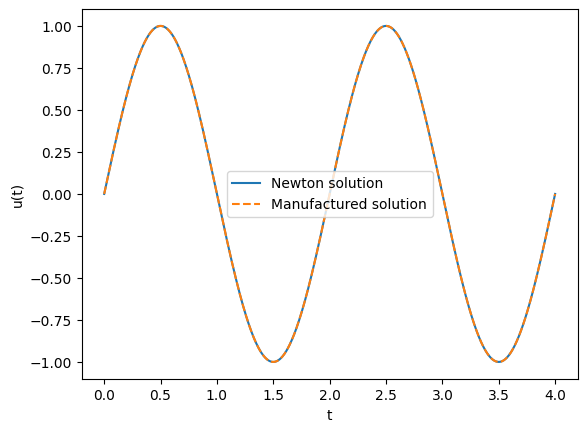

In [11]:
t_plot = np.linspace(0.0, T, 1000)

plt.plot(t_plot, u_h_evaluator.evaluate(t_plot), label="Newton solution")
plt.plot(t_plot, u(t_plot), "--", label="Manufactured solution")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.show()